In [36]:
! git clone https://github.com/MilyaushaShamsutdinova/AlignScore.git

fatal: destination path 'AlignScore' already exists and is not an empty directory.


In [37]:
! pip install spacy datasets summa pytorch_lightning

In [38]:
import sys
sys.path.append('AlignScore/src')

In [39]:
from tqdm.autonotebook import tqdm
from logging import error
from datasets import load_dataset
import transformers
from random import sample
import random
import torch
import json
from nltk.translate.bleu_score import sentence_bleu
import pandas as pd
import re
import os

# data preparation

In [40]:
DATASET_HUGGINGFACE = {
    'xnli': ['MilyaShams/xnli_ru_en_10k', 'ru'],
    'ru_sts': ['ai-forever/ru-stsbenchmark-sts', 'train'],
    'rufact':['akozlova/RuFacts', 'train'],
}

In [41]:
DATASET_CONFIG = {
    'xnli': {'task': 'nli', 'text_a': 'premise', 'text_b': 'hypothesis', 'label': 'label', 'huggingface': True},
    'ru_sts': {'task': 'sts', 'text_a': 'sentence1', 'text_b': 'sentence2', 'label': 'score', 'huggingface': True},
    'rufact': {'task': 'paraphrase', 'text_a': 'evidence', 'text_b': 'claim', 'label': 'label', 'huggingface':True},
}

In [42]:
class QA2D():
    def __init__(self, batch_size=32, device='cuda', verbose=True) -> None:
        from transformers import BartTokenizer, BartForConditionalGeneration
        self.tokenizer = BartTokenizer.from_pretrained("MarkS/bart-base-qa2d")
        self.model = BartForConditionalGeneration.from_pretrained("MarkS/bart-base-qa2d").to(device)
        self.batch_size = batch_size
        self.device=device
        self.verbose = verbose

    def generate(self, questions: list, answers: list):
        assert len(questions) == len(answers)
        qa_list = []
        for q, a in zip(questions, answers):
            qa_list.append(f"question: {q} answer: {a}")
        output = []
        for qa_pairs in tqdm(
            self.chunks(qa_list, self.batch_size),
            desc="QA to Declarative",
            total=int(len(qa_list)/self.batch_size),
            disable=(not self.verbose)
        ):
            input_text = qa_pairs
            input_token = self.tokenizer(
                input_text, return_tensors='pt', padding=True, truncation=True).to(self.device)
            dec_sents = self.model.generate(
                input_token.input_ids, max_length=512)
            result = self.tokenizer.batch_decode(
                dec_sents, skip_special_tokens=True)
            output.extend(result)

        return output

    def chunks(self, lst, n):
        """Yield successive n-sized chunks from lst."""
        for i in range(0, len(lst), n):
            yield lst[i:i + n]

In [43]:
class QAnswering():
    """
    To answer not-answerable questions
    """

    def __init__(self, batch_size=32, device='cuda') -> None:
        from transformers import T5Tokenizer, T5ForConditionalGeneration
        self.tokenizer = T5Tokenizer.from_pretrained(
            "valhalla/t5-base-qa-qg-hl")
        self.model = T5ForConditionalGeneration.from_pretrained(
            "valhalla/t5-base-qa-qg-hl").to(device)
        self.batch_size = batch_size
        self.device = device

    def generate(self, questions: list, contexts: list):
        assert len(questions) == len(contexts)
        answers = []
        for qs, cs in tqdm(zip(self.chunks(questions, self.batch_size), self.chunks(contexts, self.batch_size)), desc="Generating Answers for not answerable", total=int(len(questions)/self.batch_size)):
            qc_pairs = []
            assert len(qs) == len(cs)
            for one_q, one_c in zip(qs, cs):
                qc_pairs.append(f"""question: {one_q} context: {one_c}""")
            input_ids = self.tokenizer(
                qc_pairs, padding=True, truncation=True, return_tensors='pt').to(self.device).input_ids
            outputs = self.model.generate(input_ids, max_length=512)
            answers.extend(self.tokenizer.batch_decode(
                outputs, skip_special_tokens=True))

        return answers

    def chunks(self, lst, n):
        """Yield successive n-sized chunks from lst."""
        for i in range(0, len(lst), n):
            yield lst[i:i + n]


In [44]:
class MLMGeneratorWithPairedData():
    def __init__(self, corpra: list, device='cuda', batch_size=8, mask_percent=0.25) -> None:
        self.device = device
        self.tokenizer = transformers.DistilBertTokenizer.from_pretrained(
            "distilbert-base-uncased")
        self.model = transformers.DistilBertForMaskedLM.from_pretrained(
            "distilbert-base-uncased").to(self.device)
        self.mask_percent = mask_percent
        self.batch_size = batch_size

        self.dataset = corpra  # text needs to be noised

    def chunks(self, lst, n):
        """Yield successive n-sized chunks from lst."""
        for i in range(0, len(lst), n):
            yield lst[i:i + n]

    def generate(self):
        sents_output = []
        for examples in tqdm(self.chunks(self.dataset, self.batch_size), total=int(len(self.dataset)/self.batch_size), desc="MLM Generating"):
            sents_to_be_noised = [each for each in examples]
            sents_noised = self.mlm_infiller(sents_to_be_noised)

            sents_output.extend(sents_noised)

        return sents_output

    def mlm_infiller(self, batch):
        """
        input a batch of sentences, list
        """
        masked_batch = []
        masked_batch_ids = []
        for each_sent in batch:
            sent_tokens = self.tokenizer.tokenize(each_sent)
            sent_token_ids = self.tokenizer(each_sent)['input_ids']
            mask_list = sample(list(range(len(sent_tokens))), int(
                self.mask_percent * len(sent_tokens)))
            sent_tokens = [
                each if i not in mask_list else self.tokenizer.mask_token for i, each in enumerate(sent_tokens)]
            masked_batch_ids.append(
                [each if i-1 not in mask_list else self.tokenizer.mask_token_id for i, each in enumerate(sent_token_ids)])
            masked_batch.append(' '.join(sent_tokens))

        inputs = self.tokenizer(
            masked_batch, padding=True, truncation=True, return_tensors="pt").to(self.device)
        with torch.no_grad():
            logits = self.model(**inputs).logits

        infill_tokens = []
        for i in range(len(masked_batch)):
            mask_token_index = (inputs.input_ids == self.tokenizer.mask_token_id)[
                i].nonzero(as_tuple=True)[0]

            predicted_token_id = logits[i, mask_token_index].argmax(axis=-1)
            infill_tokens.append(predicted_token_id)

        infilled_sent = []
        for masked_sent_ids, infill_token in zip(masked_batch_ids, infill_tokens):
            for infill_one_token in infill_token:
                for i, each_id in enumerate(masked_sent_ids):
                    if each_id == self.tokenizer.mask_token_id:
                        masked_sent_ids[i] = infill_one_token
                        break
            infilled_sent.append(self.tokenizer.decode(
                masked_sent_ids, skip_special_tokens=True))

        return infilled_sent

In [45]:
class ExtractiveSummarizationGenerator():
    def __init__(self) -> None:
        pass

    def generate(self, texts):
        '''
        texts: list of string
        '''
        from summa.summarizer import summarize

        summaries = []
        for text in tqdm(texts, desc="Extracting Summary"):
            for prop in range(1, 20):
                summ = summarize(text, ratio=prop/20.)
                if len(summ) > 0:
                    break
            summaries.append(summ)

        return summaries

In [46]:
class DataGenerator():
    def __init__(self, dataset_names) -> None:
        self.dataset_names = dataset_names
        self.datasets = dict()
        self.t5_qa = None
        self.t5_tokenizer = None

        self.load_dataset_from_huggingface()

    def load_dataset_from_huggingface(self):
        for each_dataset in self.dataset_names:
            if DATASET_CONFIG[each_dataset].get('huggingface'):
                self.datasets[each_dataset] = load_dataset(
                    *DATASET_HUGGINGFACE[each_dataset][:-1],trust_remote_code=True)[DATASET_HUGGINGFACE[each_dataset][-1]]
            elif DATASET_CONFIG[each_dataset].get('using_hf_api'):
                self.datasets[each_dataset] = load_dataset(
                    *DATASET_HUGGINGFACE[each_dataset][:-1], data_dir=DATASET_CONFIG[each_dataset]['data_dir'],trust_remote_code=True)[DATASET_HUGGINGFACE[each_dataset][-1]]
            elif DATASET_CONFIG[each_dataset].get('using_pandas'):
                if DATASET_CONFIG[each_dataset]['data_path'].split('.')[-1] == 'tsv':
                    self.datasets[each_dataset] = pd.read_csv(
                        DATASET_CONFIG[each_dataset]['data_path'], sep='\t')
                elif DATASET_CONFIG[each_dataset]['data_path'].split('.')[-1] == 'csv':
                    self.datasets[each_dataset] = pd.read_csv(
                        DATASET_CONFIG[each_dataset]['data_path'])
            elif DATASET_CONFIG[each_dataset].get('using_json'):
                self.datasets[each_dataset] = []
                if DATASET_CONFIG[each_dataset].get('raw_json'):
                    with open(DATASET_CONFIG[each_dataset]['data_path'], 'r', encoding='utf8') as f:
                        self.datasets[each_dataset] = json.load(f)
                else:
                    try:
                        json_file = json.load(
                            open(DATASET_CONFIG[each_dataset]['data_path'], 'r', encoding='utf8'))
                        for example in json_file:
                            self.datasets[each_dataset].append(example)
                    except:
                        with open(DATASET_CONFIG[each_dataset]['data_path'], 'r', encoding='utf8') as f:
                            for example in f:
                                self.datasets[each_dataset].append(
                                    json.loads(example))
            else:
                error('unable to locate raw dataset...')

    def process_stsb(self):
        output = []
        for example in tqdm(self.datasets['stsb'], desc=f'Constructing stsb'):
            text_a = example[DATASET_CONFIG['stsb']['text_a']]
            text_b = [example[DATASET_CONFIG['stsb']['text_b']]]
            text_c = []
            label = example[DATASET_CONFIG['stsb']['label']] / 5.0

            output.append({
                'text_a': text_a,
                'text_b': text_b,
                'text_c': text_c,
                'label': label
            })

        return output

    def init_qa_t5(self):
        from transformers import T5Tokenizer, T5ForConditionalGeneration
        if self.t5_qa is None:
            self.t5_tokenizer = T5Tokenizer.from_pretrained(
                "t5-base", model_max_length=800)
            self.t5_qa = T5ForConditionalGeneration.from_pretrained("t5-base")
            self.t5_qa.to('cuda:1')
            self.t5_qa.eval()

    @staticmethod
    def mask_answer(context, answers):
        answers = sorted(answers, key=len, reverse=True)
        for answer in answers:
            pattern = f'(?<![\w\\-\u2013]){re.escape(answer)}(?![\w\\-\u2013])'
            context = re.sub(pattern, '', context, flags=re.IGNORECASE)
        return context

    def generate_fake_answer(self, context, question, answers):
        self.init_qa_t5()

        context_no_answer = self.mask_answer(context, answers)

        input_ids = self.t5_tokenizer(
            f'question: {question} context: {context_no_answer}',
            return_tensors="pt",
            truncation='only_first'
        ).input_ids.to(self.t5_qa.device)

        outputs = self.t5_qa.generate(
            input_ids,
            max_new_tokens=40,
            remove_invalid_values=True
        )

        return self.t5_tokenizer.decode(outputs[0], skip_special_tokens=True)

    def negative_sample_qa(self, samples, negative_sample_no_ans_only=True):
        outputs = []
        for context, question, answers in samples:
            if answers:
                outputs.append({
                    'text_a': context,
                    'text_b': [question],
                    'text_c': answers,
                    'label': 1
                })
            if not answers or not negative_sample_no_ans_only:
                fake_answer = self.generate_fake_answer(
                    context, question, answers)
                outputs.append({
                    'text_a': context,
                    'text_b': [question],
                    'text_c': [fake_answer],
                    'label': 0
                })

        return outputs

    def process_xnli(self):
        output = []
        for example in tqdm(self.datasets['xnli'], desc=f'Constructing xnli'):
            text_a = example[DATASET_CONFIG['xnli']['text_a']]
            text_b = [example[DATASET_CONFIG['xnli']['text_b']]]
            text_c = []
            label = example[DATASET_CONFIG['xnli']['label']]
            output.append({
                'text_a': text_a,
                'text_b': text_b,
                'text_c': text_c,
                'label': label
            })

        return output

    def process_rufact(self):
        output = []
        for example in tqdm(self.datasets['rufact'], desc=f'Constructing rufact'):
            text_a = example[DATASET_CONFIG['rufact']['text_a']]
            text_b = [example[DATASET_CONFIG['rufact']['text_b']]]
            text_c = []
            label = example[DATASET_CONFIG['rufact']['label']]
            output.append({
                'text_a': text_a,
                'text_b': text_b,
                'text_c': text_c,
                'label': label
            })

        return output

    def process_ru_sts(self):
        output = []
        for example in tqdm(self.datasets['ru_sts'], desc=f'Constructing ru_sts'):
            text_a = example[DATASET_CONFIG['ru_sts']['text_a']]
            text_b = [example[DATASET_CONFIG['ru_sts']['text_b']]]
            text_c = []
            label = example[DATASET_CONFIG['ru_sts']['label']]
            output.append({
                'text_a': text_a,
                'text_b': text_b,
                'text_c': text_c,
                'label': label
            })
        return output

    def generate(self):
        if not os.path.exists('./data/training'):
            os.makedirs('./data/training')
        for each_dataset in self.datasets:
            with open(f'./data/training/{each_dataset}.json', 'w', encoding='utf8') as outfile:
                outfile.write("")
        for each_dataset in self.datasets:
            outputs = eval(f'self.process_{each_dataset}()')

            for each_output in outputs:
                dict_write_to_file = {
                    'task': DATASET_CONFIG[each_dataset]['task'],
                    'text_a': each_output['text_a'],  # string
                    # list of positive examples
                    'text_b': each_output['text_b'],
                    # list of negative examples
                    'text_c': each_output['text_c'],
                    # original label, if -1 only has positive pairs and negative pairs
                    'orig_label': each_output['label']
                }
                with open(f'./data/training/{each_dataset}.json', 'a', encoding='utf8') as outfile:
                    json.dump(dict_write_to_file, outfile, ensure_ascii=False)
                    outfile.write('\n')


In [47]:
if __name__ == "__main__":
    random.seed(42)
    gen = DataGenerator(list(DATASET_CONFIG.keys()))
    gen.generate()

Constructing xnli:   0%|          | 0/10000 [00:00<?, ?it/s]

Constructing ru_sts:   0%|          | 0/5224 [00:00<?, ?it/s]

Constructing rufact:   0%|          | 0/4677 [00:00<?, ?it/s]

# Training

In [48]:
from pytorch_lightning import Trainer, seed_everything
from alignscore.dataloader import DSTDataLoader
from pytorch_lightning.callbacks import ModelCheckpoint
from argparse import ArgumentParser
import os

In [49]:
import math
from typing import Optional, Tuple
from transformers import AdamW, get_linear_schedule_with_warmup, AutoConfig
from transformers import BertForPreTraining, BertModel, RobertaModel, AlbertModel, AlbertForMaskedLM, RobertaForMaskedLM
import torch
import torch.nn as nn
import pytorch_lightning as pl
from sklearn.metrics import f1_score
from dataclasses import dataclass

class BERTAlignModel(pl.LightningModule):
    def __init__(self, model='bert-base-uncased', using_pretrained=True, *args, **kwargs) -> None:
        super().__init__()
        # Already defined in lightning: self.device
        self.save_hyperparameters()
        self.model = model

        if 'muppet' in model:
            assert using_pretrained == True, "Only support pretrained muppet!"
            self.base_model = RobertaModel.from_pretrained(model)
            self.mlm_head = RobertaForMaskedLM(AutoConfig.from_pretrained(model)).lm_head

        elif 'roberta' in model:
            if using_pretrained:
                self.base_model = RobertaModel.from_pretrained(model)
                self.mlm_head = RobertaForMaskedLM.from_pretrained(model).lm_head
            else:
                self.base_model = RobertaModel(AutoConfig.from_pretrained(model))
                self.mlm_head = RobertaForMaskedLM(AutoConfig.from_pretrained(model)).lm_head

        elif 'albert' in model:
            if using_pretrained:
                self.base_model = AlbertModel.from_pretrained(model)
                self.mlm_head = AlbertForMaskedLM.from_pretrained(model).predictions
            else:
                self.base_model = AlbertModel(AutoConfig.from_pretrained(model))
                self.mlm_head = AlbertForMaskedLM(AutoConfig.from_pretrained(model)).predictions

        elif 'bert' in model:
            if using_pretrained:
                self.base_model = BertModel.from_pretrained(model)
                self.mlm_head = BertForPreTraining.from_pretrained(model).cls.predictions
            else:
                self.base_model = BertModel(AutoConfig.from_pretrained(model))
                self.mlm_head = BertForPreTraining(AutoConfig.from_pretrained(model)).cls.predictions

        elif 'electra' in model:
            self.generator = BertModel(AutoConfig.from_pretrained('prajjwal1/bert-small'))
            self.generator_mlm = BertForPreTraining(AutoConfig.from_pretrained('prajjwal1/bert-small')).cls.predictions

            self.base_model = BertModel(AutoConfig.from_pretrained('bert-base-uncased'))
            self.discriminator_predictor = ElectraDiscriminatorPredictions(self.base_model.config)


        self.bin_layer = nn.Linear(self.base_model.config.hidden_size, 2)
        self.tri_layer = nn.Linear(self.base_model.config.hidden_size, 3)
        self.reg_layer = nn.Linear(self.base_model.config.hidden_size, 1)

        self.dropout = nn.Dropout(p=0.1)

        self.need_mlm = True
        self.is_finetune = False
        self.mlm_loss_factor = 0.5

        self.softmax = nn.Softmax(dim=-1)
        self.validation_step_outputs = []

    def forward(self, batch):
        if 'electra' in self.model:
            return self.electra_forward(batch)
        base_model_output = self.base_model(
                input_ids = batch['input_ids'],
                attention_mask = batch['attention_mask'],
                token_type_ids = batch['token_type_ids'] if 'token_type_ids' in batch.keys() else None
            )

        prediction_scores = self.mlm_head(base_model_output.last_hidden_state) ## sequence_output for mlm
        seq_relationship_score = self.bin_layer(self.dropout(base_model_output.pooler_output)) ## pooled output for classification
        tri_label_score = self.tri_layer(self.dropout(base_model_output.pooler_output))
        reg_label_score = self.reg_layer(base_model_output.pooler_output)

        total_loss = None
        if 'mlm_label' in batch.keys(): ### 'mlm_label' and 'align_label' when training
            ce_loss_fct = nn.CrossEntropyLoss(reduction='sum')
            masked_lm_loss = ce_loss_fct(prediction_scores.view(-1, self.base_model.config.vocab_size), batch['mlm_label'].view(-1)) #/ self.con vocabulary
            next_sentence_loss = ce_loss_fct(seq_relationship_score.view(-1, 2), batch['align_label'].view(-1)) / math.log(2)
            tri_label_loss = ce_loss_fct(tri_label_score.view(-1, 3), batch['tri_label'].view(-1)) / math.log(3)
            reg_label_loss = self.mse_loss(reg_label_score.view(-1), batch['reg_label'].view(-1), reduction='sum')

            masked_lm_loss_num = torch.sum(batch['mlm_label'].view(-1) != -100)
            next_sentence_loss_num = torch.sum(batch['align_label'].view(-1) != -100)
            tri_label_loss_num = torch.sum(batch['tri_label'].view(-1) != -100)
            reg_label_loss_num = torch.sum(batch['reg_label'].view(-1) != -100.0)

        return ModelOutput(
            loss=total_loss,
            all_loss=[masked_lm_loss, next_sentence_loss, tri_label_loss, reg_label_loss]  if 'mlm_label' in batch.keys() else None,
            loss_nums=[masked_lm_loss_num, next_sentence_loss_num, tri_label_loss_num, reg_label_loss_num] if 'mlm_label' in batch.keys() else None,
            prediction_logits=prediction_scores,
            seq_relationship_logits=seq_relationship_score,
            tri_label_logits=tri_label_score,
            reg_label_logits=reg_label_score,
            hidden_states=base_model_output.hidden_states,
            attentions=base_model_output.attentions
        )

    def electra_forward(self, batch):
        if 'mlm_label' in batch.keys():
            ce_loss_fct = nn.CrossEntropyLoss()
            generator_output = self.generator_mlm(self.generator(
                input_ids = batch['input_ids'],
                attention_mask = batch['attention_mask'],
                token_type_ids = batch['token_type_ids'] if 'token_type_ids' in batch.keys() else None
            ).last_hidden_state)
            masked_lm_loss = ce_loss_fct(generator_output.view(-1, self.generator.config.vocab_size), batch['mlm_label'].view(-1))

            hallucinated_tokens = batch['input_ids'].clone()

            hallucinated_tokens[batch['mlm_label']!=-100] = torch.argmax(generator_output, dim=-1)[batch['mlm_label']!=-100]
            replaced_token_label = (batch['input_ids'] == hallucinated_tokens).long()#.type(torch.LongTensor) #[batch['mlm_label'] == -100] = -100
            replaced_token_label[batch['mlm_label']!=-100] = (batch['mlm_label'] == hallucinated_tokens)[batch['mlm_label']!=-100].long()
            replaced_token_label[batch['input_ids'] == 0] = -100 ### ignore paddings

        base_model_output = self.base_model(
            input_ids = hallucinated_tokens if 'mlm_label' in batch.keys() else batch['input_ids'],
            attention_mask = batch['attention_mask'],
            token_type_ids = batch['token_type_ids'] if 'token_type_ids' in batch.keys() else None
        )
        hallu_detect_score = self.discriminator_predictor(base_model_output.last_hidden_state)
        seq_relationship_score = self.bin_layer(self.dropout(base_model_output.pooler_output)) ## pooled output for classification
        tri_label_score = self.tri_layer(self.dropout(base_model_output.pooler_output))
        reg_label_score = self.reg_layer(base_model_output.pooler_output)

        total_loss = None

        if 'mlm_label' in batch.keys(): ### 'mlm_label' and 'align_label' when training
            total_loss = []
            ce_loss_fct = nn.CrossEntropyLoss()
            hallu_detect_loss = ce_loss_fct(hallu_detect_score.view(-1,2),replaced_token_label.view(-1))
            next_sentence_loss = ce_loss_fct(seq_relationship_score.view(-1, 2), batch['align_label'].view(-1))
            tri_label_loss = ce_loss_fct(tri_label_score.view(-1, 3), batch['tri_label'].view(-1))
            reg_label_loss = self.mse_loss(reg_label_score.view(-1), batch['reg_label'].view(-1))

            total_loss.append(10.0 * hallu_detect_loss if not torch.isnan(hallu_detect_loss).item() else 0.)
            total_loss.append(0.2 * masked_lm_loss if (not torch.isnan(masked_lm_loss).item() and self.need_mlm) else 0.)
            total_loss.append(next_sentence_loss if not torch.isnan(next_sentence_loss).item() else 0.)
            total_loss.append(tri_label_loss if not torch.isnan(tri_label_loss).item() else 0.)
            total_loss.append(reg_label_loss if not torch.isnan(reg_label_loss).item() else 0.)

            total_loss = sum(total_loss)

        return ModelOutput(
            loss=total_loss,
            all_loss=[masked_lm_loss, next_sentence_loss, tri_label_loss, reg_label_loss, hallu_detect_loss]  if 'mlm_label' in batch.keys() else None,
            prediction_logits=hallu_detect_score,
            seq_relationship_logits=seq_relationship_score,
            tri_label_logits=tri_label_score,
            reg_label_logits=reg_label_score,
            hidden_states=base_model_output.hidden_states,
            attentions=base_model_output.attentions
        )

    def training_step(self, train_batch, batch_idx):
        output = self(train_batch)
        total_loss = self._training_step_end({'losses': output.all_loss, 'loss_nums': output.loss_nums})
        return {'losses': output.all_loss, 'loss_nums': output.loss_nums,'loss':total_loss}

    def _training_step_end(self, step_output):
        losses = step_output['losses']
        loss_nums = step_output['loss_nums']
        assert len(loss_nums) == len(losses), 'loss_num should be the same length as losses'

        loss_mlm_num = torch.sum(loss_nums[0])
        loss_bin_num = torch.sum(loss_nums[1])
        loss_tri_num = torch.sum(loss_nums[2])
        loss_reg_num = torch.sum(loss_nums[3])

        loss_mlm = torch.sum(losses[0]) / loss_mlm_num if loss_mlm_num > 0 else 0.
        loss_bin = torch.sum(losses[1]) / loss_bin_num if loss_bin_num > 0 else 0.
        loss_tri = torch.sum(losses[2]) / loss_tri_num if loss_tri_num > 0 else 0.
        loss_reg = torch.sum(losses[3]) / loss_reg_num if loss_reg_num > 0 else 0.

        total_loss = self.mlm_loss_factor * loss_mlm + loss_bin + loss_tri + loss_reg

        self.log('train_loss', total_loss)# , sync_dist=True
        self.log('mlm_loss', loss_mlm)
        self.log('bin_label_loss', loss_bin)
        self.log('tri_label_loss', loss_tri)
        self.log('reg_label_loss', loss_reg)

        return total_loss

    def validation_step(self, val_batch, batch_idx):
        if not self.is_finetune:
            with torch.no_grad():
                output = self(val_batch)
            self.validation_step_outputs.append(self._validation_step_end({'losses': output.all_loss, 'loss_nums': output.loss_nums}))
            return {'losses': output.all_loss, 'loss_nums': output.loss_nums}


        with torch.no_grad():
            output = self(val_batch)['seq_relationship_logits']
            output = self.softmax(output)[:, 1].tolist()
            pred = [int(align_prob>0.5) for align_prob in output]
            labels = val_batch['align_label'].tolist()

        self.validation_step_outputs.append({"pred": pred, 'labels': labels})
        return {"pred": pred, 'labels': labels}#, "preds":preds, "labels":x['labels']}

    def _validation_step_end(self, step_output):
        losses = step_output['losses']
        loss_nums = step_output['loss_nums']
        assert len(loss_nums) == len(losses), 'loss_num should be the same length as losses'

        loss_mlm_num = torch.sum(loss_nums[0])
        loss_bin_num = torch.sum(loss_nums[1])
        loss_tri_num = torch.sum(loss_nums[2])
        loss_reg_num = torch.sum(loss_nums[3])

        loss_mlm = torch.sum(losses[0]) / loss_mlm_num if loss_mlm_num > 0 else 0.
        loss_bin = torch.sum(losses[1]) / loss_bin_num if loss_bin_num > 0 else 0.
        loss_tri = torch.sum(losses[2]) / loss_tri_num if loss_tri_num > 0 else 0.
        loss_reg = torch.sum(losses[3]) / loss_reg_num if loss_reg_num > 0 else 0.

        total_loss = self.mlm_loss_factor * loss_mlm + loss_bin + loss_tri + loss_reg

        self.log('train_loss', total_loss)# , sync_dist=True
        self.log('mlm_loss', loss_mlm)
        self.log('bin_label_loss', loss_bin)
        self.log('tri_label_loss', loss_tri)
        self.log('reg_label_loss', loss_reg)

        return total_loss

    def on_validation_epoch_end(self):
        if not self.is_finetune:
            total_loss = torch.stack(self.validation_step_outputs).mean()
            self.log("val_loss", total_loss, prog_bar=True, sync_dist=True)
        else:
            all_predictions = []
            all_labels = []
            for each_output in self.validation_step_outputs:
                all_predictions.extend(each_output['pred'])
                all_labels.extend(each_output['labels'])
            self.log("f1", f1_score(all_labels, all_predictions), prog_bar=True, sync_dist=True)

    def configure_optimizers(self):
        """Prepare optimizer and schedule (linear warmup and decay)"""
        no_decay = ["bias", "LayerNorm.weight"]
        optimizer_grouped_parameters = [
            {
                "params": [p for n, p in self.named_parameters() if not any(nd in n for nd in no_decay)],
                "weight_decay": self.hparams.weight_decay,
            },
            {
                "params": [p for n, p in self.named_parameters() if any(nd in n for nd in no_decay)],
                "weight_decay": 0.0,
            },
        ]
        optimizer = AdamW(optimizer_grouped_parameters, lr=self.hparams.learning_rate, eps=self.hparams.adam_epsilon)

        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=int(self.hparams.warmup_steps_portion * self.trainer.estimated_stepping_batches),
            num_training_steps=self.trainer.estimated_stepping_batches,
        )
        scheduler = {"scheduler": scheduler, "interval": "step", "frequency": 1}
        return [optimizer], [scheduler]

    def mse_loss(self, input, target, ignored_index=-100.0, reduction='mean'):
        mask = (target == ignored_index)
        out = (input[~mask]-target[~mask])**2
        if reduction == "mean":
            return out.mean()
        elif reduction == "sum":
            return out.sum()

class ElectraDiscriminatorPredictions(nn.Module):
    """Prediction module for the discriminator, made up of two dense layers."""

    def __init__(self, config):
        super().__init__()

        self.dense = nn.Linear(config.hidden_size, config.hidden_size)
        self.dense_prediction = nn.Linear(config.hidden_size, 2)
        self.config = config
        self.gelu = nn.GELU()

    def forward(self, discriminator_hidden_states):
        hidden_states = self.dense(discriminator_hidden_states)
        hidden_states = self.gelu(hidden_states)
        logits = self.dense_prediction(hidden_states).squeeze(-1)

        return logits

@dataclass
class ModelOutput():
    loss: Optional[torch.FloatTensor] = None
    all_loss: Optional[list] = None
    loss_nums: Optional[list] = None
    prediction_logits: torch.FloatTensor = None
    seq_relationship_logits: torch.FloatTensor = None
    tri_label_logits: torch.FloatTensor = None
    reg_label_logits: torch.FloatTensor = None
    hidden_states: Optional[Tuple[torch.FloatTensor]] = None
    attentions: Optional[Tuple[torch.FloatTensor]] = None

In [50]:
ALL_TRAINING_DATASETS = {
        ### NLI
        'xnli': {'task_type': 'nli', 'data_path': 'xnli.json'},

        ### paraphrase
        'rufact': {'task_type': 'paraphrase', 'data_path': 'rufact.json'},

        ### STS
        'ru_sts': {'task_type': 'sts', 'data_path': 'ru_sts.json'},
    }


In [51]:
if not os.path.exists('ckpt'):
    os.makedirs('ckpt')

In [52]:
args = {}
args['seed']=2025
args['batch_size']=12
args['accumulate_grad_batch']=1
args['num_epoch']=3
args['num_workers']=8
args['warm_up_proportion']=0.06
args['adam_epsilon']=1e-6
args['weight_decay']=0.1
args['learning_rate']=1e-5
args['val_check_interval']=1. /4
args['devices']=[0]
args['model_name']='DeepPavlov/rubert-base-cased'
args['ckpt_save_path']='./ckpt'
args['ckpt_comment']=""
args['trainin_datasets']=list(ALL_TRAINING_DATASETS.keys())
args['data_path']='./data/training'
args['max_samples_per_dataset']=500000
args['do_mlm']=False
args['use_pretrained_model']=True

In [53]:
seed_everything(args['seed'])

2025

In [54]:

model = BERTAlignModel(model=args['model_name'],
        using_pretrained=args['use_pretrained_model'],
        adam_epsilon=args['adam_epsilon'],
        learning_rate=args['learning_rate'],
        weight_decay=args['weight_decay'],
        warmup_steps_portion=args['warm_up_proportion']
    )

Some weights of the model checkpoint at DeepPavlov/rubert-base-cased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [55]:
datasets = {
        name: {
            **ALL_TRAINING_DATASETS[name],
            "size": args['max_samples_per_dataset'],
            "data_path": os.path.join(args['data_path'], ALL_TRAINING_DATASETS[name]['data_path'])
        }
        for name in args['trainin_datasets']
    }

In [56]:
def train(datasets, args):
    dm = DSTDataLoader(
        dataset_config=datasets,
        model_name=args['model_name'],
        sample_mode='seq',
        train_batch_size=args['batch_size'],
        eval_batch_size=16,
        num_workers=args['num_workers'],
        train_eval_split=0.95,
        need_mlm=args['do_mlm']
    )
    dm.setup()

    model = BERTAlignModel(model=args['model_name'],
        using_pretrained=args['use_pretrained_model'],
        adam_epsilon=args['adam_epsilon'],
        learning_rate=args['learning_rate'],
        weight_decay=args['weight_decay'],
        warmup_steps_portion=args['warm_up_proportion']
    )
    model.need_mlm = args['do_mlm']

    training_dataset_used = '_'.join(datasets.keys())
    checkpoint_name = '_'.join((
        f"{args['ckpt_comment']}{args['model_name'].replace('/', '-')}",
        f"{'scratch_' if not args['use_pretrained_model'] else ''}{'no_mlm_' if not args['do_mlm'] else ''}{training_dataset_used}",
        str(args['max_samples_per_dataset']),
        f"{args['batch_size']}x{len(args['devices'])}x{args['accumulate_grad_batch']}"
    ))

    checkpoint_callback = ModelCheckpoint(
        dirpath=args['ckpt_save_path'],
        filename=checkpoint_name + "_{epoch:02d}_{step}",
        every_n_train_steps=10000,
        save_top_k=1
    )
    trainer = Trainer(
        accelerator="gpu",
        max_epochs=args['num_epoch'],
        #devices=args['devices'],
        strategy= "auto", #"ddp_notebook",
        precision=16,
        callbacks=[checkpoint_callback],
        accumulate_grad_batches=args['accumulate_grad_batch']
    )

    trainer.fit(model, datamodule=dm)
    trainer.save_checkpoint(os.path.join(args['ckpt_save_path'], f"{checkpoint_name}_final.ckpt"))

    print("Training is finished.")

In [57]:
train(datasets, args)

Some weights of the model checkpoint at DeepPavlov/rubert-base-cased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
/usr/local/lib/python3.10/dist-packages/lightning_fabric/connector.py:572: `precision=16` is supported for histo

Already Initilized LightningDataModule!


/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Training is finished.


In [63]:
from logging import warning
import spacy
from nltk.tokenize import sent_tokenize
import torch
from transformers import AutoConfig, AutoTokenizer
import torch.nn as nn
from tqdm import tqdm
import nltk
nltk.download('punkt_tab')
class Inferencer():
    def __init__(self, ckpt_path, model='bert-base-uncased', batch_size=32, device='cuda', verbose=True) -> None:
        self.device = device
        if ckpt_path is not None:
            self.model = BERTAlignModel.load_from_checkpoint(checkpoint_path=ckpt_path, strict=False).to(self.device)
        else:
            warning('loading UNTRAINED model!')
            self.model = BERTAlignModel(model=model).to(self.device)

        self.tokenizer_max_length = 512
        self.model.eval()
        self.batch_size = batch_size

        self.config = AutoConfig.from_pretrained(model)
        self.tokenizer = AutoTokenizer.from_pretrained(model)
        self.spacy = spacy.load('en_core_web_sm')

        self.loss_fct = nn.CrossEntropyLoss(reduction='none')
        self.softmax = nn.Softmax(dim=-1)

        self.smart_type = 'smart-n'
        self.smart_n_metric = 'f1'

        self.disable_progress_bar_in_inference = False

        self.nlg_eval_mode = None # bin, bin_sp, nli, nli_sp
        self.verbose = verbose

    def inference_example_batch(self, premise: list, hypo: list):
        """
        inference a example,
        premise: list
        hypo: list
        using self.inference to batch the process

        SummaC Style aggregation
        """
        self.disable_progress_bar_in_inference = True
        assert len(premise) == len(hypo), "Premise must has the same length with Hypothesis!"

        out_score = []
        for one_pre, one_hypo in tqdm(zip(premise, hypo), desc="Evaluating", total=len(premise), disable=(not self.verbose)):
            out_score.append(self.inference_per_example(one_pre, one_hypo))

        return None, torch.tensor(out_score), None

    def inference_per_example(self, premise:str, hypo: str):
        """
        inference a example,
        premise: string
        hypo: string
        using self.inference to batch the process
        """
        def chunks(lst, n):
            """Yield successive n-sized chunks from lst."""
            for i in range(0, len(lst), n):
                yield ' '.join(lst[i:i + n])

        premise_sents = sent_tokenize(premise)
        premise_sents = premise_sents or ['']

        n_chunk = len(premise.strip().split()) // 350 + 1
        n_chunk = max(len(premise_sents) // n_chunk, 1)
        premise_sents = [each for each in chunks(premise_sents, n_chunk)]

        hypo_sents = sent_tokenize(hypo)

        premise_sent_mat = []
        hypo_sents_mat = []
        for i in range(len(premise_sents)):
            for j in range(len(hypo_sents)):
                premise_sent_mat.append(premise_sents[i])
                hypo_sents_mat.append(hypo_sents[j])

        if self.nlg_eval_mode is not None:
            if self.nlg_eval_mode == 'nli_sp':
                output_score = self.inference(premise_sent_mat, hypo_sents_mat)[2][:,0] ### use NLI head OR ALIGN head
            elif self.nlg_eval_mode == 'bin_sp':
                output_score = self.inference(premise_sent_mat, hypo_sents_mat)[1] ### use NLI head OR ALIGN head
            elif self.nlg_eval_mode == 'reg_sp':
                output_score = self.inference(premise_sent_mat, hypo_sents_mat)[0] ### use NLI head OR ALIGN head

            output_score = output_score.view(len(premise_sents), len(hypo_sents)).max(dim=0).values.mean().item() ### sum or mean depends on the task/aspect
            return output_score


        output_score = self.inference(premise_sent_mat, hypo_sents_mat)[2][:,0] ### use NLI head OR ALIGN head
        output_score = output_score.view(len(premise_sents), len(hypo_sents)).max(dim=0).values.mean().item() ### sum or mean depends on the task/aspect

        return output_score


    def inference(self, premise, hypo):
        """
        inference a list of premise and hypo

        Standard aggregation
        """
        if isinstance(premise, str) and isinstance(hypo, str):
            premise = [premise]
            hypo = [hypo]

        batch = self.batch_tokenize(premise, hypo)
        output_score_reg = []
        output_score_bin = []
        output_score_tri = []

        for mini_batch in tqdm(batch, desc="Evaluating", disable=not self.verbose or self.disable_progress_bar_in_inference):
            mini_batch = mini_batch.to(self.device)
            with torch.no_grad():
                model_output = self.model(mini_batch)
                model_output_reg = model_output.reg_label_logits.cpu()
                model_output_bin = model_output.seq_relationship_logits # Temperature Scaling / 2.5
                model_output_tri = model_output.tri_label_logits

                model_output_bin = self.softmax(model_output_bin).cpu()
                model_output_tri = self.softmax(model_output_tri).cpu()
            output_score_reg.append(model_output_reg[:,0])
            output_score_bin.append(model_output_bin[:,1])
            output_score_tri.append(model_output_tri[:,:])

        output_score_reg = torch.cat(output_score_reg)
        output_score_bin = torch.cat(output_score_bin)
        output_score_tri = torch.cat(output_score_tri)

        if self.nlg_eval_mode is not None:
            if self.nlg_eval_mode == 'nli':
                output_score_nli = output_score_tri[:,0]
                return None, output_score_nli, None
            elif self.nlg_eval_mode == 'bin':
                return None, output_score_bin, None
            elif self.nlg_eval_mode == 'reg':
                return None, output_score_reg, None
            else:
                ValueError("unrecognized nlg eval mode")


        return output_score_reg, output_score_bin, output_score_tri

    def inference_reg(self, premise, hypo):
        """
        inference a list of premise and hypo

        Standard aggregation
        """
        self.model.is_reg_finetune = True
        if isinstance(premise, str) and isinstance(hypo, str):
            premise = [premise]
            hypo = [hypo]

        batch = self.batch_tokenize(premise, hypo)
        output_score = []

        for mini_batch in tqdm(batch, desc="Evaluating", disable=self.disable_progress_bar_in_inference):
            mini_batch = mini_batch.to(self.device)
            with torch.no_grad():
                model_output = self.model(mini_batch).seq_relationship_logits.cpu().view(-1)
            output_score.append(model_output)
        output_score = torch.cat(output_score)
        return output_score

    def batch_tokenize(self, premise, hypo):
        """
        input premise and hypos are lists
        """
        assert isinstance(premise, list) and isinstance(hypo, list)
        assert len(premise) == len(hypo), "premise and hypo should be in the same length."

        batch = []
        for mini_batch_pre, mini_batch_hypo in zip(self.chunks(premise, self.batch_size), self.chunks(hypo, self.batch_size)):
            try:
                mini_batch = self.tokenizer(mini_batch_pre, mini_batch_hypo, truncation='only_first', padding='max_length', max_length=self.tokenizer_max_length, return_tensors='pt')
            except:
                warning('text_b too long...')
                mini_batch = self.tokenizer(mini_batch_pre, mini_batch_hypo, truncation=True, padding='max_length', max_length=self.tokenizer_max_length , return_tensors='pt')
            batch.append(mini_batch)

        return batch
    def smart_doc(self, premise: list, hypo: list):
        """
        inference a example,
        premise: list
        hypo: list
        using self.inference to batch the process

        SMART Style aggregation
        """
        self.disable_progress_bar_in_inference = True
        assert len(premise) == len(hypo), "Premise must has the same length with Hypothesis!"
        assert self.smart_type in ['smart-n', 'smart-l']

        out_score = []
        for one_pre, one_hypo in tqdm(zip(premise, hypo), desc="Evaluating SMART", total=len(premise)):
            out_score.append(self.smart_l(one_pre, one_hypo)[1] if self.smart_type == 'smart-l' else self.smart_n(one_pre, one_hypo)[1])

        return None, torch.tensor(out_score), None

    def smart_l(self, premise, hypo):
        premise_sents = [each.text for each in self.spacy(premise).sents]
        hypo_sents = [each.text for each in self.spacy(hypo).sents]

        premise_sent_mat = []
        hypo_sents_mat = []
        for i in range(len(premise_sents)):
            for j in range(len(hypo_sents)):
                premise_sent_mat.append(premise_sents[i])
                hypo_sents_mat.append(hypo_sents[j])

        output_score = self.inference(premise_sent_mat, hypo_sents_mat)[2][:,0]
        output_score = output_score.view(len(premise_sents), len(hypo_sents))

        ### smart-l
        lcs = [[0] * (len(hypo_sents)+1)] * (len(premise_sents)+1)
        for i in range(len(premise_sents)+1):
            for j in range(len(hypo_sents)+1):
                if i != 0 and j != 0:
                    m = output_score[i-1, j-1]
                    lcs[i][j] = max([lcs[i-1][j-1]+m,
                                        lcs[i-1][j]+m,
                                        lcs[i][j-1]])

        return None, lcs[-1][-1] / len(premise_sents), None

    def smart_n(self, premise, hypo):
        ### smart-n
        n_gram = 1

        premise_sents = [each.text for each in self.spacy(premise).sents]
        hypo_sents = [each.text for each in self.spacy(hypo).sents]

        premise_sent_mat = []
        hypo_sents_mat = []
        for i in range(len(premise_sents)):
            for j in range(len(hypo_sents)):
                premise_sent_mat.append(premise_sents[i])
                hypo_sents_mat.append(hypo_sents[j])

        output_score = self.inference(premise_sent_mat, hypo_sents_mat)[2][:,0]
        output_score = output_score.view(len(premise_sents), len(hypo_sents))

        prec = sum([max([sum([output_score[i+n, j+n]/n_gram for n in range(0, n_gram)]) for i in range(len(premise_sents)-n_gram+1)]) for j in range(len(hypo_sents)-n_gram+1)])
        prec = prec / (len(hypo_sents) - n_gram + 1) if (len(hypo_sents) - n_gram + 1) > 0 else 0.


        premise_sents = [each.text for each in self.spacy(hypo).sents]# simple change
        hypo_sents = [each.text for each in self.spacy(premise).sents]#

        premise_sent_mat = []
        hypo_sents_mat = []
        for i in range(len(premise_sents)):
            for j in range(len(hypo_sents)):
                premise_sent_mat.append(premise_sents[i])
                hypo_sents_mat.append(hypo_sents[j])

        output_score = self.inference(premise_sent_mat, hypo_sents_mat)[2][:,0]
        output_score = output_score.view(len(premise_sents), len(hypo_sents))

        recall = sum([max([sum([output_score[i+n, j+n]/n_gram for n in range(0, n_gram)]) for i in range(len(premise_sents)-n_gram+1)]) for j in range(len(hypo_sents)-n_gram+1)])
        recall = prec / (len(hypo_sents) - n_gram + 1) if (len(hypo_sents) - n_gram + 1) > 0 else 0.

        f1 = 2 * prec * recall / (prec + recall)

        if self.smart_n_metric == 'f1':
            return None, f1, None
        elif self.smart_n_metric == 'precision':
            return None, prec, None
        elif self.smart_n_metric == 'recall':
            return None, recall, None
        else:
            ValueError("SMART return type error")

    def chunks(self, lst, n):
        """Yield successive n-sized chunks from lst."""
        for i in range(0, len(lst), n):
            yield lst[i:i + n]

    def nlg_eval(self, premise, hypo):
        assert self.nlg_eval_mode is not None, "Select NLG Eval mode!"
        if (self.nlg_eval_mode == 'bin') or (self.nlg_eval_mode == 'nli') or (self.nlg_eval_mode == 'reg'):
            return self.inference(premise, hypo)

        elif (self.nlg_eval_mode == 'bin_sp') or (self.nlg_eval_mode == 'nli_sp') or (self.nlg_eval_mode == 'reg_sp'):
            return self.inference_example_batch(premise, hypo)

        else:
            ValueError("Unrecognized NLG Eval mode!")

[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [64]:
from typing import List

class AlignScore:
    def __init__(self, model: str, batch_size: int, device: int, ckpt_path: str, evaluation_mode='nli_sp', verbose=True) -> None:
        self.model = Inferencer(
            ckpt_path=ckpt_path,
            model=model,
            batch_size=batch_size,
            device=device,
            verbose=verbose
        )
        self.model.nlg_eval_mode = evaluation_mode

    def score(self, contexts: List[str], claims: List[str]) -> List[float]:
        return self.model.nlg_eval(contexts, claims)[1].tolist()

# Inference example

In [65]:

scorer = AlignScore(model=args['model_name'],
                    batch_size=args['batch_size'],
                    device='cuda:0',
                    ckpt_path='/kaggle/working/ckpt/DeepPavlov-rubert-base-cased_no_mlm_xnli_rufact_ru_sts_500000_10x1x1_final.ckpt',
                    evaluation_mode='nli_sp')

Some weights of the model checkpoint at DeepPavlov/rubert-base-cased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
/usr/local/lib/python3.10/dist-packages/spacy/util.py:1740: UserWarning: [W111] Jupyter notebook detected: if us

In [66]:
score = scorer.score(contexts=['hello world.'], claims=['hello world.'])
score

Evaluating: 100%|██████████| 1/1 [00:00<00:00, 14.84it/s]


[0.9245655536651611]

# Validate

In [98]:
bin_scorer = AlignScore(model=args['model_name'],
                    batch_size=args['batch_size'],
                    device='cuda:0',
                    ckpt_path='/kaggle/working/ckpt/DeepPavlov-rubert-base-cased_no_mlm_xnli_rufact_ru_sts_500000_10x1x1_final.ckpt',
                    evaluation_mode='bin_sp')
reg_scorer = AlignScore(model=args['model_name'],
                    batch_size=args['batch_size'],
                    device='cuda:0',
                    ckpt_path='/kaggle/working/ckpt/DeepPavlov-rubert-base-cased_no_mlm_xnli_rufact_ru_sts_500000_10x1x1_final.ckpt',
                    evaluation_mode='reg_sp')
nli_scorer = AlignScore(model=args['model_name'],
                    batch_size=args['batch_size'],
                    device='cuda:0',
                    ckpt_path='/kaggle/working/ckpt/DeepPavlov-rubert-base-cased_no_mlm_xnli_rufact_ru_sts_500000_10x1x1_final.ckpt',
                    evaluation_mode='nli_sp')

Some weights of the model checkpoint at DeepPavlov/rubert-base-cased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of the model checkpoint at DeepPavlov/rubert-base-cased were not used when initializing BertModel: 

### RuFact

In [99]:
rufact = load_dataset('akozlova/RuFacts',trust_remote_code=True)['validation']
rufact

Dataset({
    features: ['idx', 'evidence', 'claim', 'label'],
    num_rows: 1559
})

In [101]:
score = bin_scorer.score(contexts=rufact['evidence'], claims=rufact['claim'])

Evaluating: 100%|██████████| 1559/1559 [01:51<00:00, 14.03it/s]


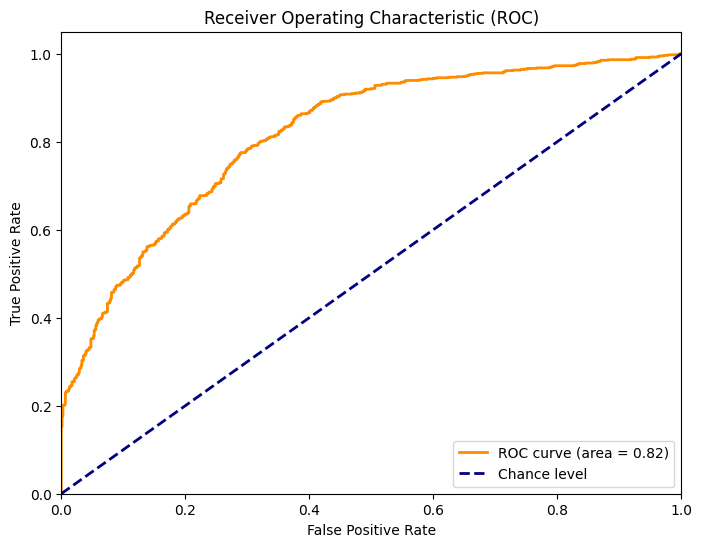

In [102]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Assuming you already have your validation set labels (y_val) and predicted probabilities (y_prob)
# For a binary classifier, y_prob should be the probability of the positive class.
# Example: y_prob = model.predict_proba(X_val)[:, 1]

# Compute false positive rate, true positive rate, and thresholds
fpr, tpr, thresholds = roc_curve(rufact['label'], score)

# Compute the area under the curve (AUC)
roc_auc = auc(fpr, tpr)

# Plotting the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:0.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Chance level')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

In [103]:
from sklearn.metrics import classification_report
import numpy as np
# Convert probabilities to binary predictions using a threshold of 0.5
y_pred = (np.array(score) >= 0.5).astype(int)

# Generate and print the classification report
print(classification_report(rufact['label'], y_pred))

              precision    recall  f1-score   support

           0       0.84      0.53      0.65       753
           1       0.67      0.91      0.77       806

    accuracy                           0.73      1559
   macro avg       0.76      0.72      0.71      1559
weighted avg       0.76      0.73      0.72      1559



In [104]:
idx = 50
row = rufact[i]
print(row)
score = bin_scorer.score(contexts=[row['evidence']], claims=[row['claim']])
print(score)

{'idx': 49, 'evidence': 'В отрочестве он попытался решить первую часть проблемы изобретательным способом, помогавшим лучше, чем таблетки (слишком слабые давали слабый сон, слишком сильные усиливали яркость чудовищных видений).', 'claim': 'В отрочестве он пытался сладить с первой бедой посредством хитроумной методы, помогавшей лучше всяких пилюль (из коих слабые насылали сон слишком краткий, а сильные усугубляли живость монструозных видений).', 'label': 0}


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 29.48it/s]

[0.3851224482059479]


### Ru STS

In [106]:
rusts = load_dataset('ai-forever/ru-stsbenchmark-sts',trust_remote_code=True)['validation']
rusts

Dataset({
    features: ['sentence1', 'score', 'sentence2'],
    num_rows: 1336
})

In [108]:
score = reg_scorer.score(contexts=rusts['sentence1'], claims=rusts['sentence2'])

Evaluating: 100%|██████████| 1336/1336 [00:43<00:00, 30.44it/s]


In [116]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_val = np.array(rusts['score'])
y_pred = np.array(score)

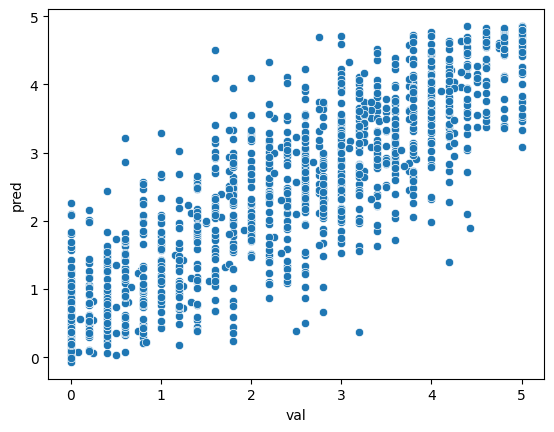

In [121]:
import seaborn as sns
sns.scatterplot(x=y_val,y=y_pred)
plt.xlabel('val')
plt.ylabel('pred')
plt.show()

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


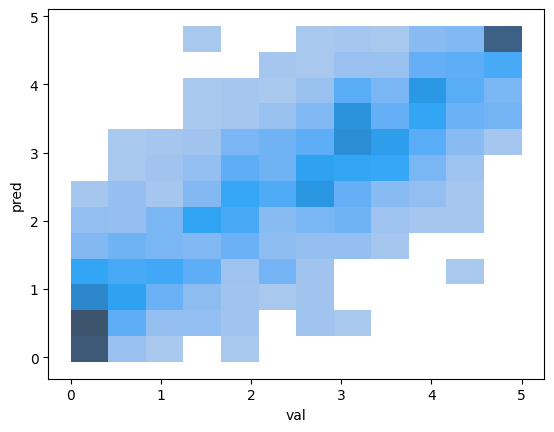

In [122]:
import seaborn as sns
sns.histplot(x=y_val,y=y_pred)
plt.xlabel('val')
plt.ylabel('pred')
plt.show()

In [117]:
mae = mean_absolute_error(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 0.5842476026350242
Mean Squared Error (MSE): 0.5671477336395743
Root Mean Squared Error (RMSE): 0.7530921149763649
R² Score: 0.7508250328003755
